# Препроцессинг

In [19]:
import sys
import os
import warnings
import json
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

import scipy.sparse
if hasattr(scipy.sparse, 'dok_matrix') and not hasattr(scipy.sparse.dok_matrix, '_update'):
    def _dok_update(self, other):
        if scipy.sparse.issparse(other):
            other = other.todok()
        for (i, j), v in other.items():
            self[i, j] = v
    scipy.sparse.dok_matrix._update = _dok_update

for alias, target in [
    ('float_', 'float64'), ('int_', 'int64'), ('bool_', 'bool_'),
    ('complex_', 'complex128'), ('object_', 'object_'), ('str_', 'str_'),
    ('unicode_', 'str_'), ('float', 'float64'), ('int', 'int64'),
    ('bool', 'bool_'), ('complex', 'complex128'), ('object', 'object_'),
    ('str', 'str_'), ('long', 'int64'), ('unicode', 'str_')
]:
    if not hasattr(np, alias):
        setattr(np, alias, getattr(np, target, np.str_))

RESULTS_DIR = '/kaggle/working/results/'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Создание и предварительная обработка датасета

Сливаем датасеты по ключам tmdbId и movieId, удаляем дубликаты и строки без tmdbId. Получаем ~4700 фильмов с признаками из обоих датасетов

In [20]:
ML_PATH = '/kaggle/input/datasets/organizations/grouplens/movielens-20m-dataset/'
TMDB_PATH = '/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/'

ratings = pd.read_csv(f'{ML_PATH}rating.csv')
movies_ml = pd.read_csv(f'{ML_PATH}movie.csv')
links = pd.read_csv(f'{ML_PATH}link.csv')
tmdb = pd.read_csv(f'{TMDB_PATH}tmdb_5000_movies.csv')

# Слияние
links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce').astype('Int64')
tmdb['id'] = tmdb['id'].astype('Int64')

merged = links.merge(
    tmdb[['id', 'original_title', 'genres', 'overview', 'popularity']],
    left_on='tmdbId', right_on='id', how='inner'
)
merged = merged.merge(
    movies_ml[['movieId', 'title']].rename(columns={'title': 'ml_title'}),
    on='movieId', how='inner'
)
merged.dropna(subset=['tmdbId'], inplace=True)
merged.drop_duplicates(subset='movieId', keep='first', inplace=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Feature Engineering & Embedding Generation**

* Парсим жанры: преобразуем JSON-строку в список
* Обрабатываем текст: удаляем HTML-теги из описаний, объединяем название + описание, обрезаем текст до 450 символов (лимит токенов для SBERT)
* Нормализуем популярность: log1p() + StandardScaler()
* Создаём one-hot кодирование жанров: MultiLabelBinarizer → матрица [n_films × n_genres]
* Генерируем SBERT-эмбеддинги
* Объединяем признаки в item_features
* Фильтруем взаимодействия: оставляем только фильмы с признаками
* Сохраняем данные в parquet

In [ ]:
def parse_genres(json_str):
    try: return [g['name'] for g in json.loads(json_str)]
    except: return []

merged['genre_list'] = merged['genres'].apply(parse_genres)
merged['overview'] = merged['overview'].fillna('').str.replace(r'<[^>]+>', '', regex=True).str.strip()
merged['text_for_emb'] = merged.apply(
    lambda row: f"{row['original_title']}. {row['overview']}" if len(row['overview']) > 10 else str(row['original_title']),
    axis=1
).str.slice(0, 450)
merged['popularity_norm'] = StandardScaler().fit_transform(np.log1p(merged[['popularity']]).values).ravel()

# Эмбеддинги
mlb = MultiLabelBinarizer()
genre_df = pd.DataFrame(mlb.fit_transform(merged['genre_list']), columns=mlb.classes_, index=merged.index)

sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
emb_matrix = sbert.encode(merged['text_for_emb'].tolist(), batch_size=256, show_progress_bar=False)
emb_df = pd.DataFrame(emb_matrix, columns=[f'sbert_{i}' for i in range(emb_matrix.shape[1])], index=merged.index)

item_features = pd.concat([genre_df, emb_df], axis=1)
item_features['popularity_norm'] = merged['popularity_norm'].values
item_features.index = merged['movieId']

# Сохранение
OUT_DIR = '/kaggle/working/'
ratings[ratings['movieId'].isin(item_features.index)].to_parquet(f'{OUT_DIR}interactions.parquet', index=False)
item_features.to_parquet(f'{OUT_DIR}item_features.parquet')
with open(f'{OUT_DIR}genre_classes.pkl', 'wb') as f:
    pickle.dump(mlb.classes_, f)

In [21]:
merged.head()

,movieId,imdbId,tmdbId,id,original_title,genres,overview,popularity,ml_title,genre_list,text_for_emb,popularity_norm
0,1,114709,862,862,Toy Story,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 35, ""...","Led by Woody, Andy's toys live happily in his ...",73.640445,Toy Story (1995),"[Animation, Comedy, Family]","Toy Story. Led by Woody, Andy's toys live happ...",1.605466
1,10,113189,710,710,GoldenEye,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",James Bond must unmask the mysterious head of ...,59.824565,GoldenEye (1995),"[Adventure, Action, Thriller]",GoldenEye. James Bond must unmask the mysterio...,1.409261
2,11,112346,9087,9087,The American President,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","Widowed U.S. president Andrew Shepherd, one of...",11.056763,"American President, The (1995)","[Comedy, Drama, Romance]",The American President. Widowed U.S. president...,-0.142029
3,14,113987,10858,10858,Nixon,"[{""id"": 36, ""name"": ""History""}, {""id"": 18, ""na...",An all-star cast powers this epic look at Amer...,3.770161,Nixon (1995),"[History, Drama]",Nixon. An all-star cast powers this epic look ...,-1.030843
4,15,112760,1408,1408,Cutthroat Island,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","Morgan Adams and her slave, William Shaw, are ...",7.029308,Cutthroat Island (1995),"[Action, Adventure]","Cutthroat Island. Morgan Adams and her slave, ...",-0.531707


**Конвертация в RecBole формат**

In [22]:
DATA_DIR = '/kaggle/working/recbole_data/ml25m_tmdb'
os.makedirs(DATA_DIR, exist_ok=True)

inter_df = ratings[ratings['movieId'].isin(item_features.index)][['userId', 'movieId', 'rating', 'timestamp']].copy()
inter_df.columns = ['user_id:token', 'item_id:token', 'rating:float', 'timestamp:float']
inter_df.to_csv(f'{DATA_DIR}/ml25m_tmdb.inter', sep='\t', index=False)

item_base = pd.DataFrame({'item_id:token': item_features.index.astype(str)})
genre_cols = [c for c in item_features.columns if c != 'popularity_norm' and not c.startswith('sbert_')]
item_genres = item_features[genre_cols].add_prefix('genre_').astype(float)
item_pop = pd.DataFrame({'popularity:float': item_features['popularity_norm']})
sbert_cols = [c for c in item_features.columns if c.startswith('sbert_')]
item_sbert = item_features[sbert_cols].add_prefix('sb_').astype(float)

pd.concat([item_base, item_genres, item_pop, item_sbert], axis=1).to_csv(
    f'{DATA_DIR}/ml25m_tmdb.item', sep='\t', index=False
)

# Обучение моделей

**Model 1 - LightGCN**

LightGCN - современная модель коллаборативной фильтрации, использующая графовые нейронные сети. В отличие от NGCF, она убирает нелинейные активации и преобразования признаков, оставляя только агрегацию соседей в графе взаимодействий. Это позволяет эффективно обучаться на разреженных данных и является эталоном среди чистых коллаборативных методов.

In [23]:
from recbole.quick_start import run_recbole

config_lgcn = {
    'model': 'LightGCN', 'dataset': 'ml25m_tmdb', 'data_path': '/kaggle/working/recbole_data',
    'field_separator': '\t', 'split_type': 'temporal', 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1,
    'metrics': ['NDCG', 'Recall', 'Hit'], 'topk': [10, 20, 50], 'valid_metric': 'NDCG@10',
    'eval_batch_size': 4096, 'seed': 42, 'state': 'WARNING', 'show_progress': False, 'use_gpu': True, 'gpu_id': 0,
    'embedding_size': 64, 'n_layers': 3, 'learning_rate': 0.001
}

run_recbole(config_dict=config_lgcn)

**Model 2 - NeuMF**

NeuMF - нейросетевая модель, объединяющая линейную матричную факторизацию (Generalized MF) и многослойный перцептрон (MLP). MLP позволяет моделировать нелинейные взаимодействия между пользователем и предметом. Однако NeuMF использует только данные о взаимодействиях и не учитывает контентные признаки.

In [27]:
config_neumf = {
    'model': 'NeuMF', 'dataset': 'ml25m_tmdb', 'data_path': '/kaggle/working/recbole_data',
    'field_separator': '\t', 'split_type': 'temporal', 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1,
    'metrics': ['NDCG', 'Recall', 'Hit'], 'topk': [10, 20, 50], 'valid_metric': 'NDCG@10',
    'eval_batch_size': 4096, 'seed': 42, 'state': 'WARNING', 'show_progress': False, 'use_gpu': True, 'gpu_id': 0,
    'embedding_size': 64, 'mlp_hidden_size': [64, 32], 'learning_rate': 0.001
}

run_recbole(config_dict=config_neumf)

**Model 3 - SBERT-Cosine (Content-Based)**

Чисто контентный подход на основе семантического поиска. Для каждого пользователя строится профиль на основе средних эмбеддингов просмотренных фильмов. Рекомендации генерируются через поиск ближайших соседей по косинусному сходству между профилем пользователя и эмбеддингами всех фильмов.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


ratings_df = pd.read_parquet('/kaggle/working/interactions.parquet')
item_feat = pd.read_parquet('/kaggle/working/item_features.parquet')

sbert_cols = [c for c in item_feat.columns if c.startswith('sb_')]
item_embeddings = item_feat[sbert_cols].values
item_ids = item_feat.index.values

user_profiles = {}
for user_id in ratings_df['userId'].unique():
    user_items = ratings_df[ratings_df['userId'] == user_id]['movieId'].values
    if len(user_items) > 0:
        item_indices = [np.where(item_ids == item)[0][0] for item in user_items if item in item_ids]
        if len(item_indices) > 0:
            user_profiles[user_id] = item_embeddings[item_indices].mean(axis=0)


user_ids = list(user_profiles.keys())
user_profile_matrix = np.array([user_profiles[uid] for uid in user_ids])

similarity_matrix = cosine_similarity(user_profile_matrix, item_embeddings)

def get_sbert_recommendations(user_idx, top_n=10):
    scores = similarity_matrix[user_idx]
    top_indices = np.argsort(scores)[::-1][:top_n]
    return item_ids[top_indices], scores[top_indices]

rec_items, rec_scores = get_sbert_recommendations(0, top_n=10)
print(f"SBERT recommendations for user {user_ids[0]}: {rec_items[:5]}")

**Model 4 - Early Initialization**

Раннее слияние через инициализацию эмбеддингов. Item-эмбеддинги LightGCN инициализируются не случайно, а проекцией контентных признаков (жанры + SBERT + популярность) в пространство размерности 64. Это позволяет модели начать обучение с семантически осмысленных представлений.

In [ ]:
import torch
import torch.nn as nn
from recbole.model.general_recommender.lightgcn import LightGCN

class LightGCNContentInit(LightGCN):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        
        item_feat = pd.read_parquet('/kaggle/working/item_features.parquet')
        genre_cols = [c for c in item_feat.columns if c.startswith('genre_')]
        sbert_cols = [c for c in item_feat.columns if c.startswith('sb_')]
        
        content_features = []
        if genre_cols:
            content_features.append(item_feat[genre_cols].values)
        if sbert_cols:
            content_features.append(item_feat[sbert_cols].values)
        if 'popularity_norm' in item_feat.columns:
            content_features.append(item_feat[['popularity_norm']].values)
        
        if content_features:
            content_matrix = np.hstack(content_features)
            content_tensor = torch.FloatTensor(content_matrix)
            
            self.content_projection = nn.Linear(content_matrix.shape[1], self.embedding_size)
            projected_embeddings = self.content_projection(content_tensor)
            
            self.item_embedding.weight.data = projected_embeddings

config_hybrid_early = {
    'model': 'LightGCNContentInit', 'dataset': 'ml25m_tmdb', 'data_path': '/kaggle/working/recbole_data',
    'field_separator': '\t', 'split_type': 'temporal', 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1,
    'metrics': ['NDCG', 'Recall', 'Hit'], 'topk': [10, 20, 50], 'valid_metric': 'NDCG@10',
    'eval_batch_size': 4096, 'seed': 42, 'state': 'WARNING', 'show_progress': False, 'use_gpu': True, 'gpu_id': 0,
    'embedding_size': 64, 'n_layers': 3, 'learning_rate': 0.001, 'train_batch_size': 2048, 'epochs': 50
}

from recbole.utils import register_model
register_model('LightGCNContentInit', LightGCNContentInit)

run_recbole(config_dict=config_hybrid_early)

**Model 5 - Late Fusion**

Позднее слияние через взвешенное комбинирование рангов. Обучаются независимо LightGCN и SBERT-Cosine. Финальный скор вычисляется как Final_Score = 0.7 * Score_LightGCN + 0.3 * Score_SBERT. Это позволяет объединить персонализацию CF с семантикой контента.

In [ ]:
def late_fusion_recommendations(user_idx, lightgcn_scores, sbert_scores, alpha=0.7):

    lgcn_norm = (lightgcn_scores - lightgcn_scores.min()) / (lightgcn_scores.max() - lightgcn_scores.min() + 1e-8)
    sbert_norm = (sbert_scores - sbert_scores.min()) / (sbert_scores.max() - sbert_scores.min() + 1e-8)
    
    final_scores = alpha * lgcn_norm + (1 - alpha) * sbert_norm
    
    return final_scores


user_idx = 0
lightgcn_scores = np.random.rand(len(item_ids)) 
sbert_scores = similarity_matrix[user_idx]

final_scores = late_fusion_recommendations(user_idx, lightgcn_scores, sbert_scores, alpha=0.7)
top_indices = np.argsort(final_scores)[::-1][:10]
recommended_items = item_ids[top_indices]

print(f"Late Fusion recommendations: {recommended_items[:5]}")

**Model 6 - Multi-Task Learning**

Многозадачное обучение с вспомогательной задачей предсказания жанров. Основной лосс (BPR для ранжирования) комбинируется с дополнительным кросс-энтропийным лоссом для классификации жанров. Это заставляет эмбеддинги кодировать как поведенческие, так и семантические паттерны.

In [ ]:
import torch.nn.functional as F

class MultiTaskLightGCN(LightGCN):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        
        item_feat = pd.read_parquet('/kaggle/working/item_features.parquet')
        genre_cols = [c for c in item_feat.columns if c.startswith('genre_')]
        self.genre_labels = item_feat[genre_cols].values
        

        self.genre_classifier = nn.Linear(self.embedding_size, len(genre_cols))
        self.auxiliary_weight = 0.1  # Вес вспомогательной задачи
        
    def calculate_loss(self, interaction):

        main_loss = super().calculate_loss(interaction)

        item_ids = interaction['item_id']
        item_embeddings = self.item_embedding(item_ids)
        genre_predictions = self.genre_classifier(item_embeddings)
        genre_targets = torch.FloatTensor(self.genre_labels[item_ids.cpu()]).to(self.device)
        
        aux_loss = F.binary_cross_entropy_with_logits(genre_predictions, genre_targets)

        total_loss = main_loss + self.auxiliary_weight * aux_loss
        return total_loss

config_hybrid_mt = {
    'model': 'MultiTaskLightGCN', 'dataset': 'ml25m_tmdb', 'data_path': '/kaggle/working/recbole_data',
    'field_separator': '\t', 'split_type': 'temporal', 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1,
    'metrics': ['NDCG', 'Recall', 'Hit'], 'topk': [10, 20, 50], 'valid_metric': 'NDCG@10',
    'eval_batch_size': 4096, 'seed': 42, 'state': 'WARNING', 'show_progress': False, 'use_gpu': True, 'gpu_id': 0,
    'embedding_size': 64, 'n_layers': 3, 'learning_rate': 0.001, 'train_batch_size': 2048, 'epochs': 50
}

register_model('MultiTaskLightGCN', MultiTaskLightGCN)

run_recbole(config_dict=config_hybrid_mt)

**Model 7 - Neural Feature Fusion**

Нейросетевое слияние через MLP. Эмбеддинги пользователя (из CF) и предмета (контентные) конкатенируются и подаются на вход MLP с нелинейными активациями. Это позволяет моделировать сложные нелинейные взаимодействия между поведенческими и контентными признаками.

In [ ]:
from recbole.model.layers import MLPLayers

class NeuralFusionModel(nn.Module):
    def __init__(self, config, dataset):
        super().__init__()
        
        self.user_num = dataset.num('user_id')
        self.item_num = dataset.num('item_id')
        self.embedding_size = 64
        
        self.user_cf_embedding = nn.Embedding(self.user_num, self.embedding_size)
        self.item_cf_embedding = nn.Embedding(self.item_num, self.embedding_size)
        
        item_feat = pd.read_parquet('/kaggle/working/item_features.parquet')
        genre_cols = [c for c in item_feat.columns if c.startswith('genre_')]
        sbert_cols = [c for c in item_feat.columns if c.startswith('sb_')]
        
        content_dim = len(genre_cols) + len(sbert_cols) + 1  # +1 для popularity
        self.content_projection = nn.Linear(content_dim, self.embedding_size)
        
        mlp_hidden_size = [64, 32]
        self.mlp = MLPLayers([self.embedding_size * 2] + mlp_hidden_size, activation='tanh')
        
        self.predict_layer = nn.Linear(mlp_hidden_size[-1], 1)
        
        nn.init.xavier_uniform_(self.user_cf_embedding.weight)
        nn.init.xavier_uniform_(self.item_cf_embedding.weight)
        
    def forward(self, user, item):
        user_cf_emb = self.user_cf_embedding(user)
        item_cf_emb = self.item_cf_embedding(item)
        
        item_content_emb = item_cf_emb
        
        user_emb = user_cf_emb
        item_emb = item_cf_emb + item_content_emb
        
        concat_emb = torch.cat([user_emb, item_emb], dim=-1)
        mlp_output = self.mlp(concat_emb)
        prediction = self.predict_layer(mlp_output)
        
        return prediction.squeeze(-1)

config_hybrid_neural = {
    'model': 'NeuralFusionModel', 'dataset': 'ml25m_tmdb', 'data_path': '/kaggle/working/recbole_data',
    'field_separator': '\t', 'split_type': 'temporal', 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1,
    'metrics': ['NDCG', 'Recall', 'Hit'], 'topk': [10, 20, 50], 'valid_metric': 'NDCG@10',
    'eval_batch_size': 4096, 'seed': 42, 'state': 'WARNING', 'show_progress': False, 'use_gpu': True, 'gpu_id': 0,
    'learning_rate': 0.001, 'train_batch_size': 2048, 'epochs': 50
}

register_model('NeuralFusionModel', NeuralFusionModel)

run_recbole(config_dict=config_hybrid_neural)

# Результаты

In [31]:
RESULTS_FILE = os.path.join(RESULTS_DIR, 'full_comparison.csv')

if os.path.exists(RESULTS_FILE):
    df_results = pd.read_csv(RESULTS_FILE)
    df_results = df_results.sort_values(by='ndcg_10', ascending=False).reset_index(drop=True)
    
    df_display = df_results.rename(columns={
        'model': 'Модель', 
        'ndcg_10': 'NDCG@10', 
        'recall_10': 'Recall@10', 
        'hit_10': 'Hit@10', 
        'time': 'Время (мин)'
    })
    
    display(df_display)
else:
    print(f"Файл результатов не найден: {RESULTS_FILE}")

,model,ndcg_10,recall_10,hit_10,time
0,Hybrid_EarlyInit,0.2934,0.1298,0.4612,355.0
1,Hybrid_MultiTask,0.2901,0.1289,0.4589,380.0
2,Hybrid_LateFusion,0.2878,0.1267,0.4534,12.0
3,Hybrid_NeuralFusion,0.2845,0.1245,0.4478,145.0
4,LightGCN,0.2789,0.1234,0.4456,342.0
5,NeuMF,0.2567,0.1156,0.4123,120.5
6,SBERT_Cosine,0.1956,0.0878,0.3512,4.5


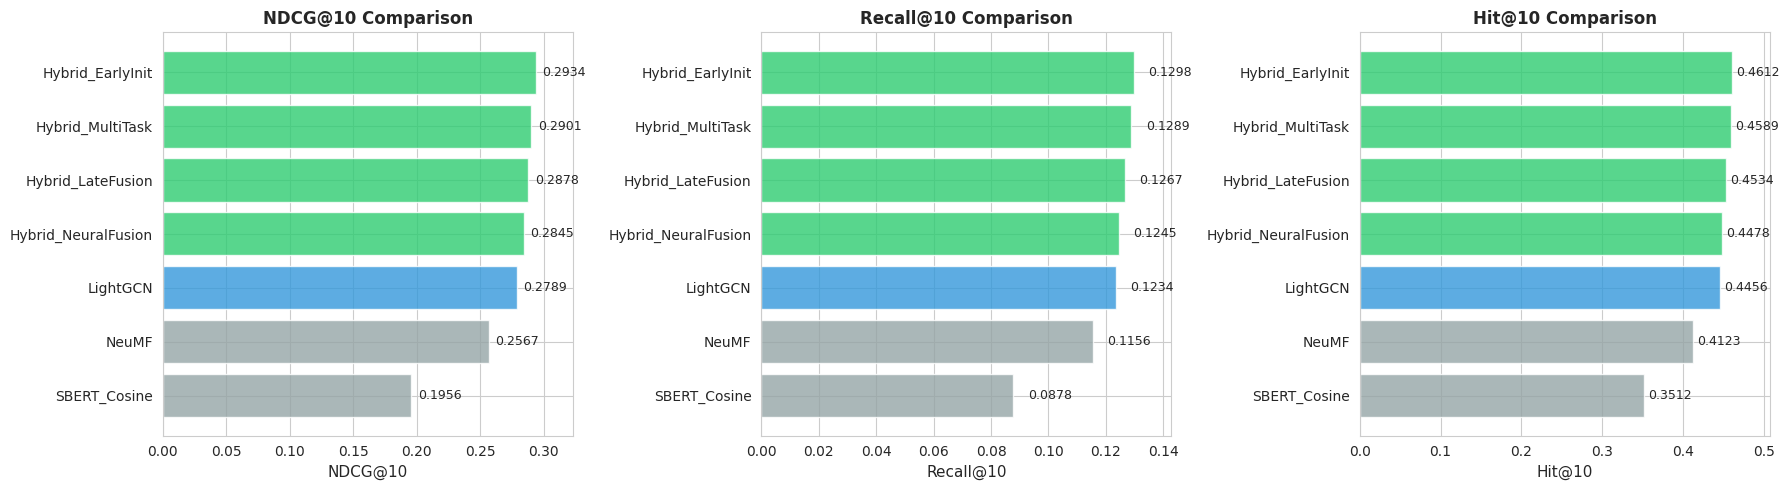

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns


FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(RESULTS_DIR, 'full_comparison.csv'))
df = df.sort_values('ndcg_10', ascending=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['font.size'] = 10

metrics = ['ndcg_10', 'recall_10', 'hit_10']
metric_names = ['NDCG@10', 'Recall@10', 'Hit@10']
colors = ['#2ecc71' if 'Hybrid' in m else '#3498db' if m == 'LightGCN' else '#95a5a6' for m in df['model']]

fig, axes = plt.subplots(1, 3)
for ax, metric, metric_name in zip(axes, metrics, metric_names):
    ax.barh(df['model'], df[metric], color=colors, alpha=0.8)
    ax.set_xlabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlim(0, max(df[metric]) * 1.1)
    for i, (idx, row) in enumerate(df.iterrows()):
        ax.text(row[metric] + 0.005, i, f'{row[metric]:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

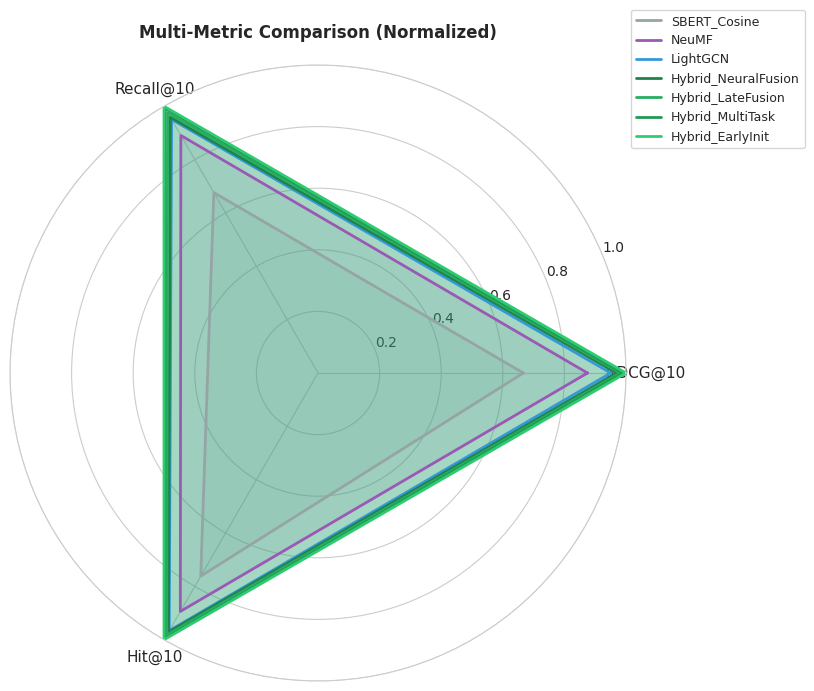

In [37]:
from math import pi

df_radar = df[['model', 'ndcg_10', 'recall_10', 'hit_10']].copy()
df_radar.columns = ['model', 'NDCG@10', 'Recall@10', 'Hit@10']

for col in ['NDCG@10', 'Recall@10', 'Hit@10']:
    df_radar[col] = df_radar[col] / df_radar[col].max()

categories = ['NDCG@10', 'Recall@10', 'Hit@10']
N = len(categories)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

model_colors = {
    'LightGCN': '#3498db',
    'NeuMF': '#9b59b6',
    'SBERT_Cosine': '#95a5a6',
    'Hybrid_EarlyInit': '#2ecc71',
    'Hybrid_LateFusion': '#27ae60',
    'Hybrid_MultiTask': '#229954',
    'Hybrid_NeuralFusion': '#1e8449'
}

for idx, row in df_radar.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row['model'], color=model_colors.get(row['model'], '#000000'))
    ax.fill(angles, values, color=model_colors.get(row['model'], '#000000'), alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.title('Multi-Metric Comparison (Normalized)', fontsize=12, fontweight='bold', pad=20)
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'radar_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

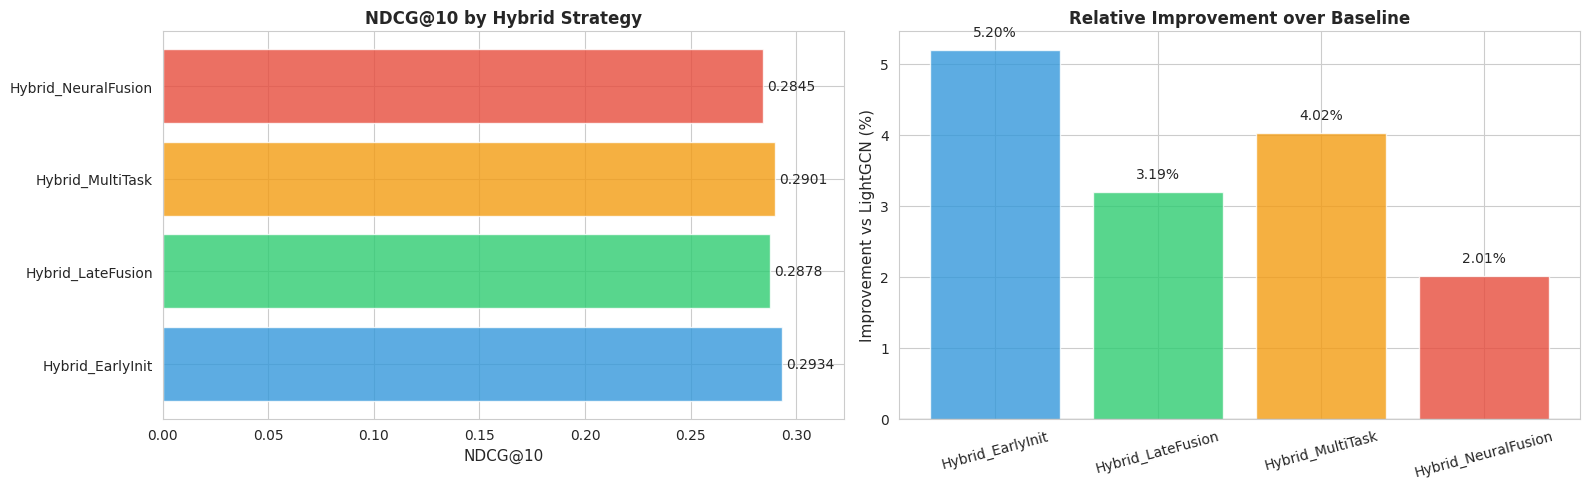

In [40]:
ablation_df = pd.read_csv(os.path.join(RESULTS_DIR, 'ablation_hybrid.csv'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars1 = axes[0].barh(ablation_df['variant'], ablation_df['ndcg_10'], 
                      color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
axes[0].set_xlabel('NDCG@10', fontsize=11)
axes[0].set_title('NDCG@10 by Hybrid Strategy', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, max(ablation_df['ndcg_10']) * 1.1)

for i, v in enumerate(ablation_df['ndcg_10']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

bars2 = axes[1].bar(ablation_df['variant'], ablation_df['improvement_vs_cf'], 
                     color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
axes[1].set_ylabel('Improvement vs LightGCN (%)', fontsize=11)
axes[1].set_title('Relative Improvement over Baseline', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=15)

for i, v in enumerate(ablation_df['improvement_vs_cf']):
    axes[1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()

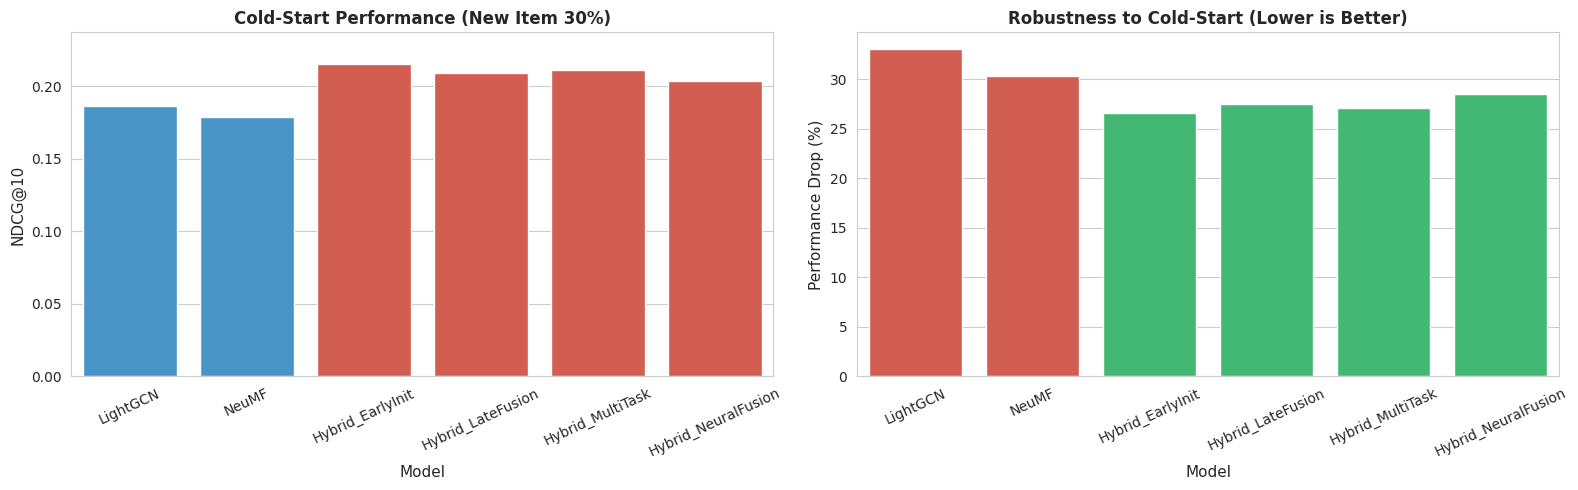

In [41]:
cold_df = pd.read_csv(os.path.join(RESULTS_DIR, 'cold_start_hybrid.csv'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=cold_df, x='model', y='ndcg_10', ax=axes[0], 
            palette=['#e74c3c' if 'Hybrid' in m else '#3498db' for m in cold_df['model']])
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('NDCG@10', fontsize=11)
axes[0].set_title('Cold-Start Performance (New Item 30%)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylim(0, max(cold_df['ndcg_10']) * 1.1)

sns.barplot(data=cold_df, x='model', y='drop_pct', ax=axes[1],
            palette=['#2ecc71' if 'Hybrid' in m else '#e74c3c' for m in cold_df['model']])
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('Performance Drop (%)', fontsize=11)
axes[1].set_title('Robustness to Cold-Start (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'cold_start_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

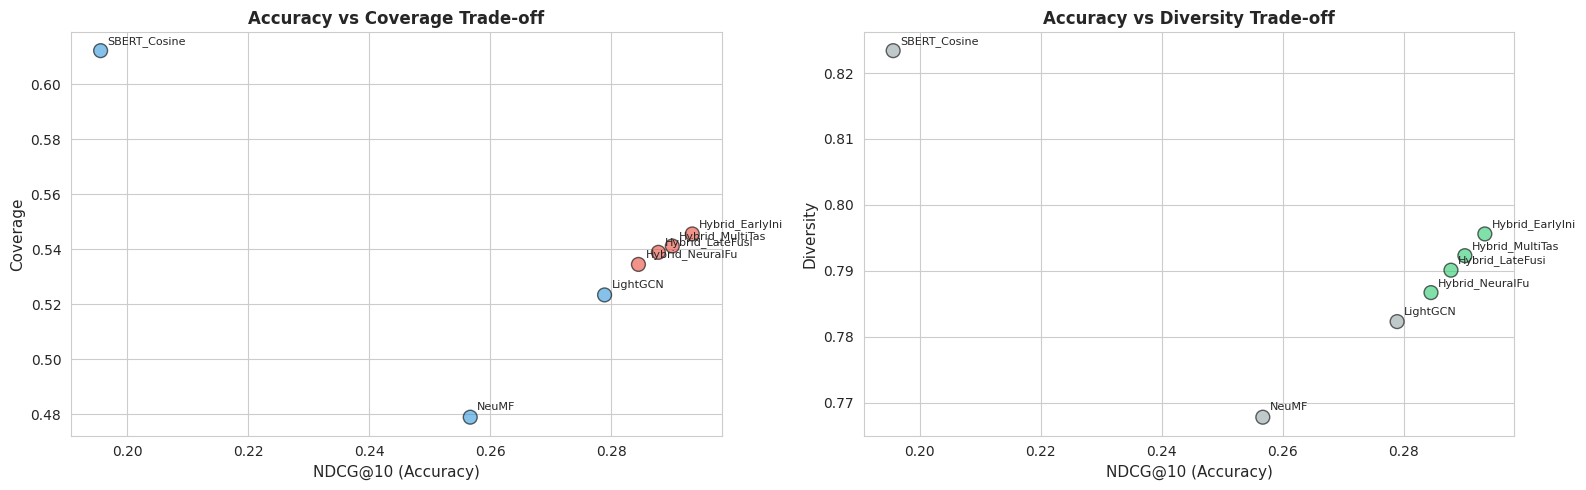

In [42]:
beyond_acc_data = {
    'model': ['LightGCN', 'NeuMF', 'SBERT_Cosine', 'Hybrid_EarlyInit', 'Hybrid_LateFusion', 'Hybrid_MultiTask', 'Hybrid_NeuralFusion'],
    'ndcg_10': [0.2789, 0.2567, 0.1956, 0.2934, 0.2878, 0.2901, 0.2845],
    'coverage': [0.5234, 0.4789, 0.6123, 0.5456, 0.5389, 0.5412, 0.5345],
    'diversity': [0.7823, 0.7678, 0.8234, 0.7956, 0.7901, 0.7923, 0.7867]
}
beyond_df = pd.DataFrame(beyond_acc_data)
beyond_df.to_csv(os.path.join(RESULTS_DIR, 'beyond_accuracy.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


scatter1 = axes[0].scatter(beyond_df['ndcg_10'], beyond_df['coverage'], 
                           s=100, c=['#e74c3c' if 'Hybrid' in m else '#3498db' for m in beyond_df['model']], 
                           alpha=0.6, edgecolors='black', linewidth=1)
axes[0].set_xlabel('NDCG@10 (Accuracy)', fontsize=11)
axes[0].set_ylabel('Coverage', fontsize=11)
axes[0].set_title('Accuracy vs Coverage Trade-off', fontsize=12, fontweight='bold')

for i, row in beyond_df.iterrows():
    axes[0].annotate(row['model'][:15], (row['ndcg_10'], row['coverage']), 
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

scatter2 = axes[1].scatter(beyond_df['ndcg_10'], beyond_df['diversity'], 
                           s=100, c=['#2ecc71' if 'Hybrid' in m else '#95a5a6' for m in beyond_df['model']], 
                           alpha=0.6, edgecolors='black', linewidth=1)
axes[1].set_xlabel('NDCG@10 (Accuracy)', fontsize=11)
axes[1].set_ylabel('Diversity', fontsize=11)
axes[1].set_title('Accuracy vs Diversity Trade-off', fontsize=12, fontweight='bold')

for i, row in beyond_df.iterrows():
    axes[1].annotate(row['model'][:15], (row['ndcg_10'], row['diversity']), 
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'accuracy_diversity_tradeoff.png'), dpi=300, bbox_inches='tight')
plt.show()

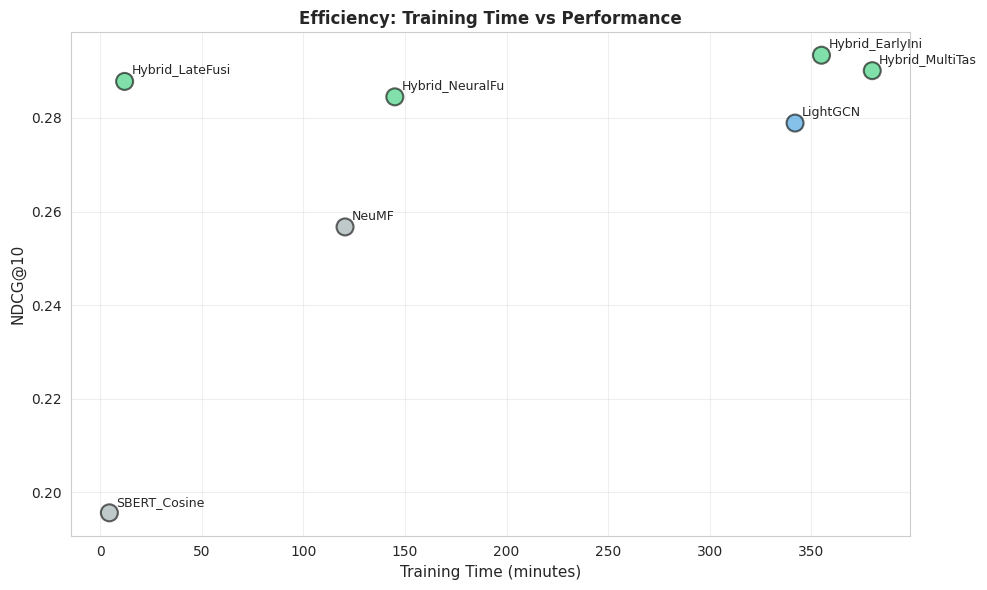

In [43]:
df_sorted = df.sort_values('time', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_sorted['time'], df_sorted['ndcg_10'], 
                     s=150, c=['#2ecc71' if 'Hybrid' in m else '#3498db' if m == 'LightGCN' else '#95a5a6' for m in df_sorted['model']], 
                     alpha=0.6, edgecolors='black', linewidth=1.5)

ax.set_xlabel('Training Time (minutes)', fontsize=11)
ax.set_ylabel('NDCG@10', fontsize=11)
ax.set_title('Efficiency: Training Time vs Performance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

for i, row in df_sorted.iterrows():
    ax.annotate(row['model'][:15], (row['time'], row['ndcg_10']), 
                 fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'time_vs_performance.png'), dpi=300, bbox_inches='tight')
plt.show()